# ============================================================
# AIML505 Project
# Group F
# Temporal GNNs for Dhaka Stock Exchange Price Forecasting
# Part 1 : Data Loading & Cleaning
# ============================================================

In [35]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## data loading

In [36]:
DATA_PATH = "./Dataset/modified/DSE_Data_Manupulation_with_Sector.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(1455180, 9)


,Row_Number,Trading_Code,Sector,Date,Open,High,Low,Close,Volume
0,0,SIBL,Bank,2025-04-08,9.9,10.0,9.8,9.9,359773.0
1,1,MEGHNALIFE,Insurance,2025-04-08,54.5,56.6,54.1,56.1,610711.0
2,2,BPML,PaperPrint,2025-04-08,41.1,41.7,40.0,40.2,482031.0
3,3,CROWNCEMNT,NaN,2025-04-08,47.9,50.9,47.5,50.0,104860.0
4,4,ATCSLGF,MutualFunds,2025-04-08,0.0,0.0,0.0,7.5,0.0


In [37]:
print(df.info())

print(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1455180 entries, 0 to 1455179
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Row_Number    1455180 non-null  int64  
 1   Trading_Code  1455180 non-null  object 
 2   Sector        1240873 non-null  object 
 3   Date          1455180 non-null  object 
 4   Open          1455180 non-null  float64
 5   High          1455180 non-null  float64
 6   Low           1455180 non-null  float64
 7   Close         1455180 non-null  float64
 8   Volume        1455180 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 99.9+ MB
None
          Row_Number Trading_Code     Sector        Date          Open  \
count   1.455180e+06      1455180    1240873     1455180  1.455180e+06   
unique           NaN          534         18        6429           NaN   
top              NaN          ACI  Insurance  2025-04-08           NaN   
freq             NaN         

In [38]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Trading_Code","Date"])

df.reset_index(drop=True, inplace=True)

In [39]:
missing = df.isnull().sum()

missing

Row_Number           0
Trading_Code         0
Sector          214307
Date                 0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
dtype: int64

In [40]:
missing_percent = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

missing_percent

Sector          14.73
Row_Number       0.00
Trading_Code     0.00
Date             0.00
Open             0.00
High             0.00
Low              0.00
Close            0.00
Volume           0.00
dtype: float64

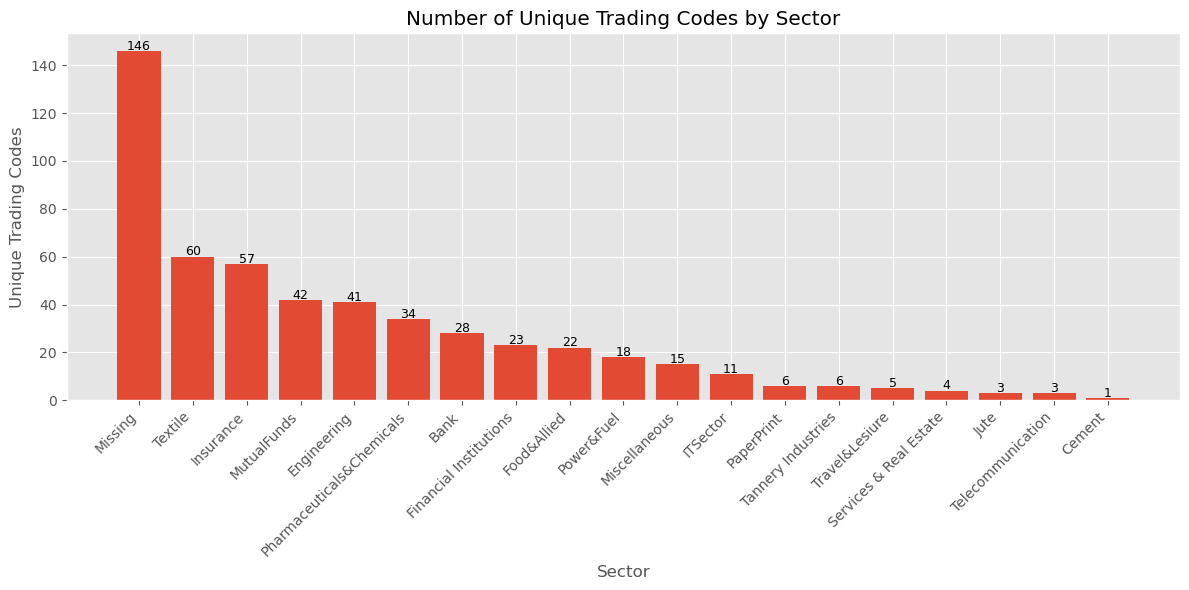

In [69]:

# Count unique Trading_Code per Sector
sector_counts = (
    df[['Trading_Code', 'Sector']]
    .drop_duplicates(subset='Trading_Code')   # Count each Trading_Code only once
    .fillna({'Sector': 'Missing'})
    .groupby('Sector')['Trading_Code']
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(sector_counts.index, sector_counts.values)

plt.title("Number of Unique Trading Codes by Sector")
plt.xlabel("Sector")
plt.ylabel("Unique Trading Codes")

plt.xticks(rotation=45, ha='right')

# Add value labels
for i, v in enumerate(sector_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

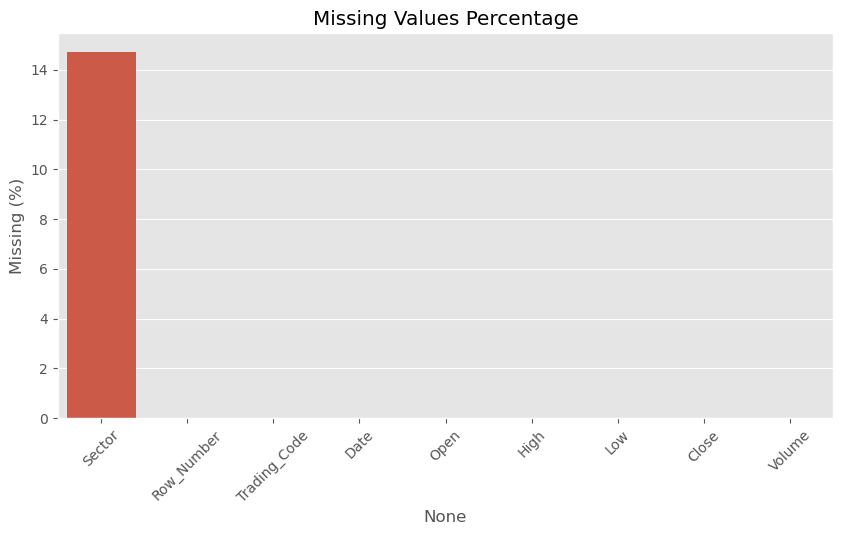

In [41]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_percent.index,
    y=missing_percent.values
)

plt.xticks(rotation=45)
plt.ylabel("Missing (%)")
plt.title("Missing Values Percentage")

plt.show()

In [42]:
duplicate_rows = df.duplicated()

print("Duplicate Rows :", duplicate_rows.sum())

Duplicate Rows : 0


In [43]:
print("Number of Companies :", df["Trading_Code"].nunique())

Number of Companies : 534


In [44]:
print(df["Sector"].nunique())

print(df["Sector"].unique())

18
['MutualFunds' 'ITSector' 'Bank' nan 'Textile' 'Pharmaceuticals&Chemicals'
 'Engineering' 'Insurance' 'Miscellaneous' 'Food&Allied' 'Power&Fuel'
 'Tannery Industries' 'Financial Institutions' 'Travel&Lesiure'
 'PaperPrint' 'Telecommunication' 'Services & Real Estate' 'Jute' 'Cement']


In [45]:
print("Start :", df["Date"].min())

print("End   :", df["Date"].max())

print("Days  :", df["Date"].nunique())

Start : 1999-01-02 00:00:00
End   : 2025-04-08 00:00:00
Days  : 6429


In [46]:
price_cols = [
    "Open",
    "High",
    "Low",
    "Close"
]

df[price_cols].describe()

,Open,High,Low,Close
count,1.455180e+06,1.455180e+06,1.455180e+06,1.455180e+06
mean,2.627589e+02,2.666387e+02,2.586847e+02,8.312747e+02
std,1.180814e+03,1.187056e+03,1.174227e+03,2.376911e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.800000e+01,1.830000e+01,1.770000e+01,1.870000e+01
50%,4.480000e+01,4.550000e+01,4.400000e+01,4.610000e+01
75%,1.792125e+02,1.820000e+02,1.763000e+02,1.887000e+02
max,1.037500e+06,1.037500e+06,1.037500e+06,1.037500e+06


In [47]:
df = df[
    (df["Open"] > 0) &
    (df["High"] > 0) &
    (df["Low"] > 0) &
    (df["Close"] > 0)
]

In [48]:
invalid = df[
    (df["High"] < df["Low"]) |
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"])
]
print(invalid)
print(invalid.shape)

         Row_Number Trading_Code                     Sector       Date  \
58883        937766   AIBL1STIMF                MutualFunds 2014-12-15   
81480        710445       ALLTEX                    Textile 2017-11-14   
101256       937828   ANLIMAYARN                    Textile 2014-12-15   
171761       937730    AZIZPIPES                Engineering 2014-12-15   
240906       937753    BDWELDING                        NaN 2014-12-15   
368194       680269          DBH     Financial Institutions 2018-03-27   
409772      1003957         DSES                        NaN 2014-01-04   
412504       748246         DSEX                        NaN 2017-05-29   
414192      1207743     DSHGARME                    Textile 2010-08-31   
463297      1236179          EHL     Services & Real Estate 2010-03-08   
479978       937637    EXIM1STMF                MutualFunds 2014-12-15   
503217       937825        FBFIF                MutualFunds 2014-12-15   
546616       830176      GENNEXT      

In [49]:
df = df.drop(invalid.index)

In [50]:
df["Return"] = (
    df.groupby("Trading_Code")["Close"]
      .pct_change()
)

df["Log_Return"] = np.log(
    df["Close"] /
    df.groupby("Trading_Code")["Close"].shift(1)
)

In [51]:
df["MA_7"] = (
    df.groupby("Trading_Code")["Close"]
      .transform(lambda x: x.rolling(7).mean())
)

df["MA_30"] = (
    df.groupby("Trading_Code")["Close"]
      .transform(lambda x: x.rolling(30).mean())
)

In [52]:
df["Volatility_30"] = (
    df.groupby("Trading_Code")["Return"]
      .transform(lambda x: x.rolling(30).std())
)

In [53]:
print(df.info())

print(df.head())


<class 'pandas.core.frame.DataFrame'>
Index: 1433137 entries, 0 to 1455179
Data columns (total 14 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Row_Number     1433137 non-null  int64         
 1   Trading_Code   1433137 non-null  object        
 2   Sector         1228564 non-null  object        
 3   Date           1433137 non-null  datetime64[ns]
 4   Open           1433137 non-null  float64       
 5   High           1433137 non-null  float64       
 6   Low            1433137 non-null  float64       
 7   Close          1433137 non-null  float64       
 8   Volume         1433137 non-null  float64       
 9   Return         1432612 non-null  float64       
 10  Log_Return     1432612 non-null  float64       
 11  MA_7           1430026 non-null  float64       
 12  MA_30          1418257 non-null  float64       
 13  Volatility_30  1417747 non-null  float64       
dtypes: datetime64[ns](1), float64(10), int6

# EDA


In [54]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print(df.columns)

Rows : 1433137
Columns : 14
Index(['Row_Number', 'Trading_Code', 'Sector', 'Date', 'Open', 'High', 'Low',
       'Close', 'Volume', 'Return', 'Log_Return', 'MA_7', 'MA_30',
       'Volatility_30'],
      dtype='object')


In [55]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row_Number,1433137.0,795521.560909,0.0,448751.0,807048.0,1165624.0,1523920.0,431699.922963
Date,1433137,2015-11-16 11:37:23.565269248,1999-01-02 00:00:00,2011-05-31 00:00:00,2016-08-30 00:00:00,2021-02-24 00:00:00,2025-04-08 00:00:00,NaN
Open,1433137.0,266.782744,0.67,18.8,46.0,184.0,1037500.0,1189.391966
High,1433137.0,270.722513,0.67,19.1,46.9,187.0,1037500.0,1195.67102
Low,1433137.0,262.646173,0.67,18.5,45.2,181.0,1037500.0,1182.765827
Close,1433137.0,266.196024,0.67,18.7,45.9,183.5,1037500.0,1188.512041
Volume,1433137.0,694594.877172,0.0,7265.0,63186.0,324800.0,295392690.0,5548920.074801
Return,1432612.0,0.017092,-0.997951,-0.022187,0.0,0.02008,487.0,0.719593
Log_Return,1432612.0,-0.000261,-6.190572,-0.022437,0.0,0.019881,6.190315,0.16265
MA_7,1430026.0,265.500358,0.68,18.9,46.285714,187.178571,38123.107143,803.183116


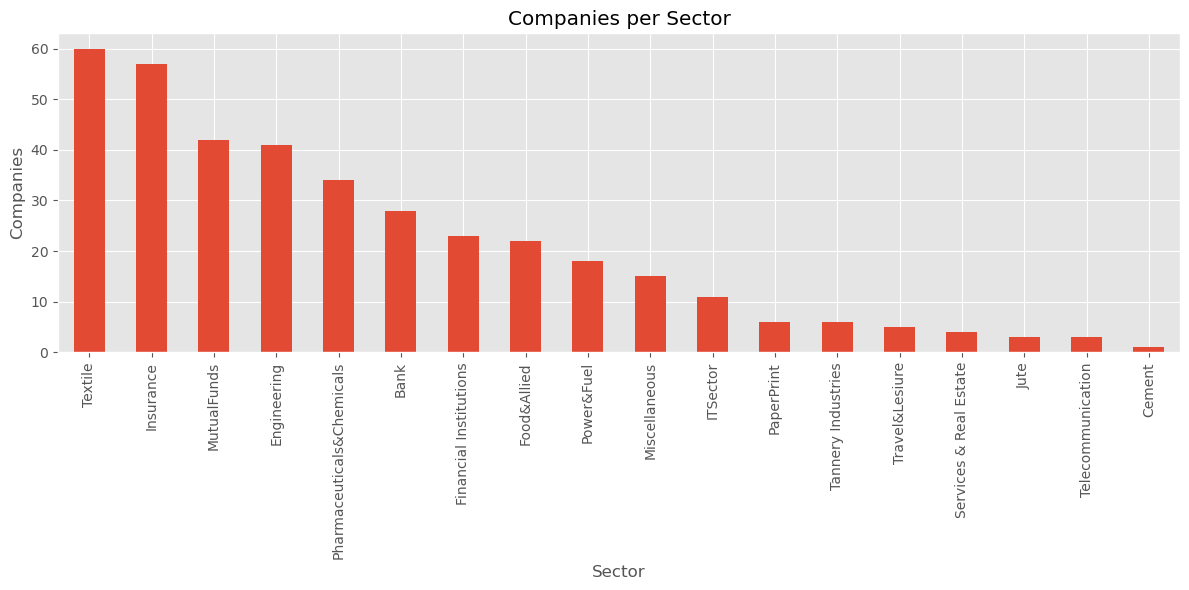

In [56]:
sector_count = (
    df.groupby("Sector")["Trading_Code"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sector_count.plot(kind="bar")

plt.ylabel("Companies")

plt.title("Companies per Sector")

plt.tight_layout()

plt.show()

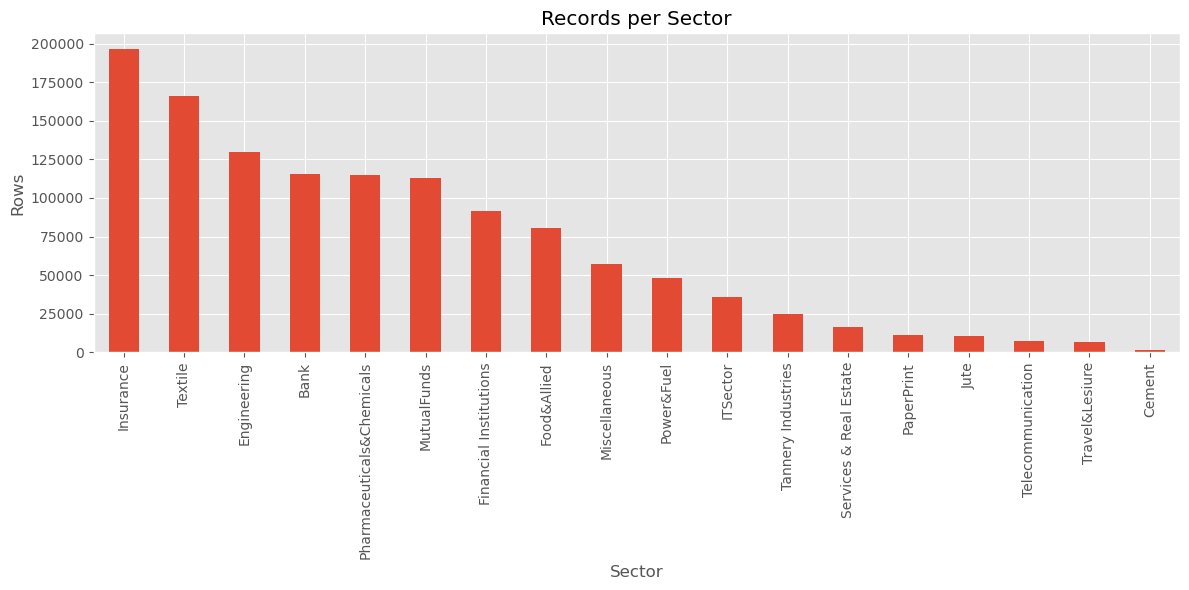

In [57]:
records = (
    df.groupby("Sector")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

records.plot(kind="bar")

plt.ylabel("Rows")

plt.title("Records per Sector")

plt.tight_layout()

plt.show()

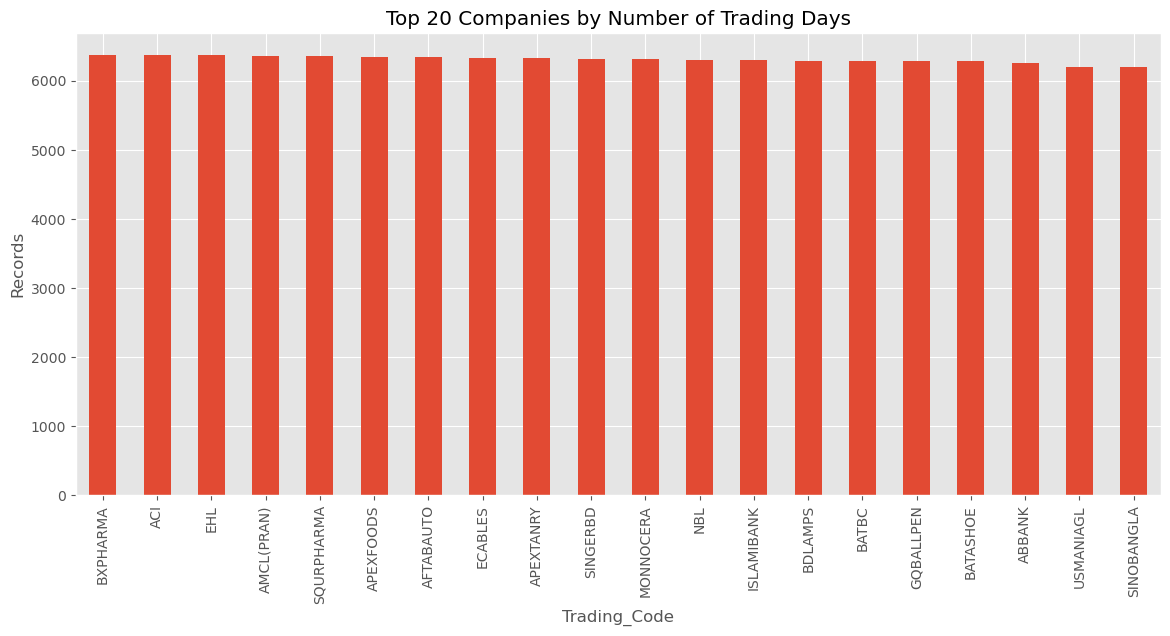

In [58]:
top_stock = (
    df["Trading_Code"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(14,6))

top_stock.plot(kind="bar")

plt.ylabel("Records")

plt.title("Top 20 Companies by Number of Trading Days")

plt.show()

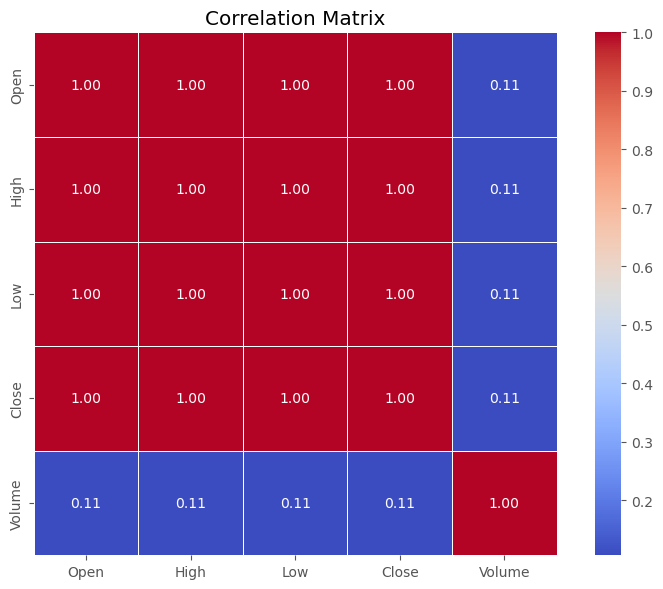

In [59]:
# Correlation Matrix

columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

corr = df[columns].corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

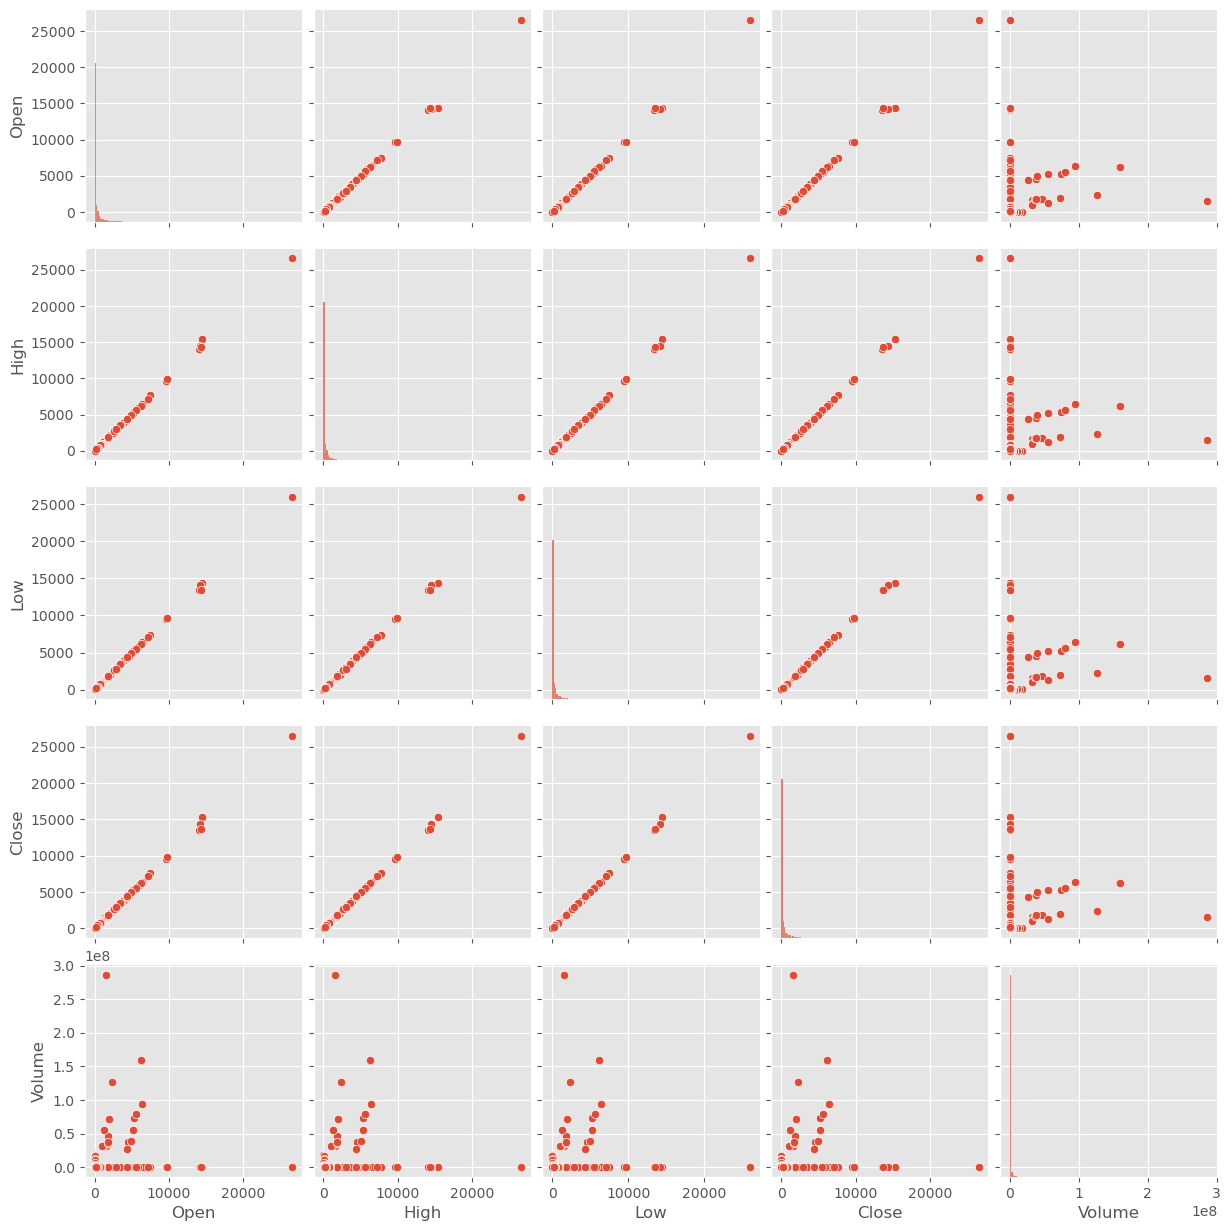

In [60]:
sample = df.sample(5000, random_state=42)

sns.pairplot(
    sample[
        ["Open","High","Low","Close","Volume"]
    ]
)

plt.show()

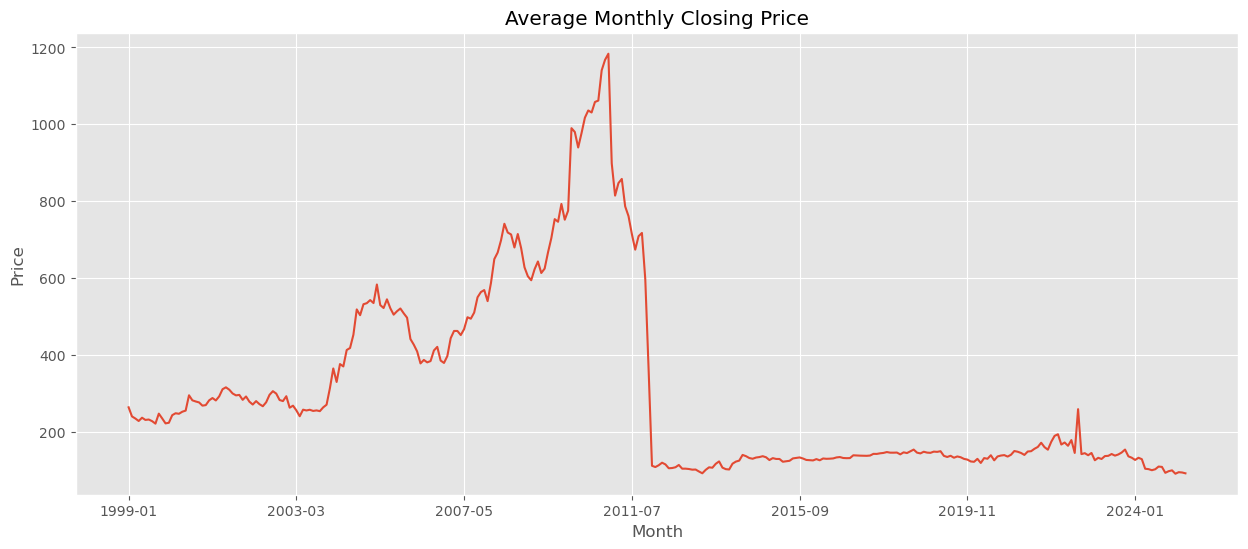

In [61]:
monthly = df.copy()

monthly["Month"] = monthly["Date"].dt.to_period("M")

monthly = (
    monthly.groupby("Month")["Close"]
           .mean()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(15,6))

monthly.plot()

plt.title("Average Monthly Closing Price")

plt.ylabel("Price")

plt.show()

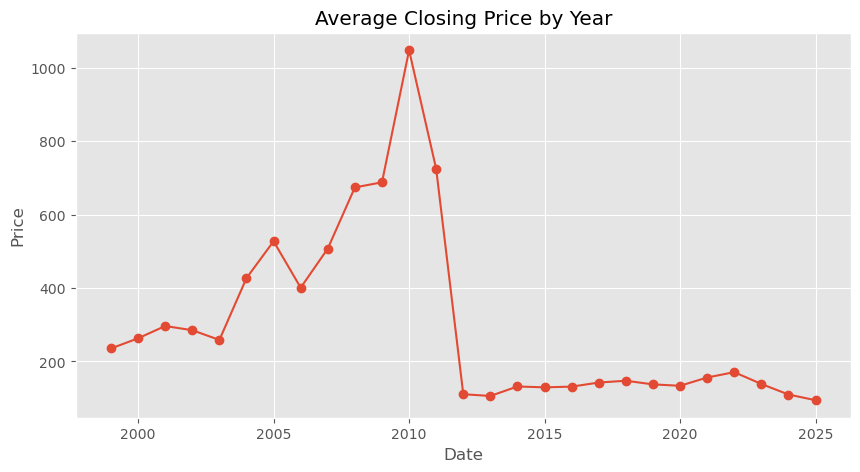

In [62]:
yearly = (
    df.groupby(df["Date"].dt.year)["Close"]
      .mean()
)

plt.figure(figsize=(10,5))

yearly.plot(marker="o")

plt.title("Average Closing Price by Year")

plt.ylabel("Price")

plt.show()

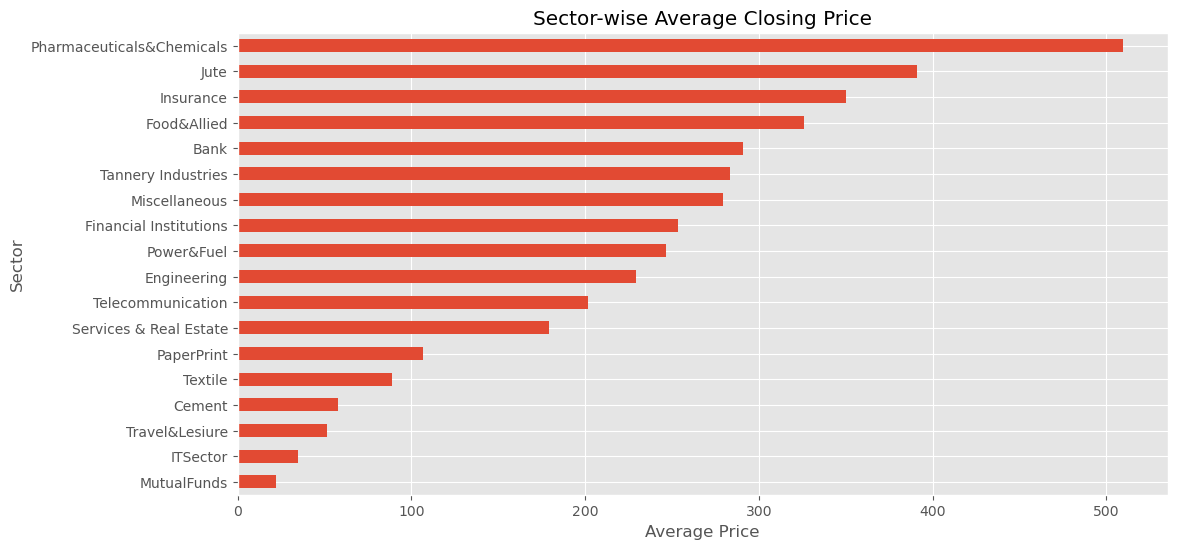

In [63]:
sector_price = (
    df.groupby("Sector")["Close"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

sector_price.plot(kind="barh")

plt.xlabel("Average Price")

plt.title("Sector-wise Average Closing Price")

plt.show()

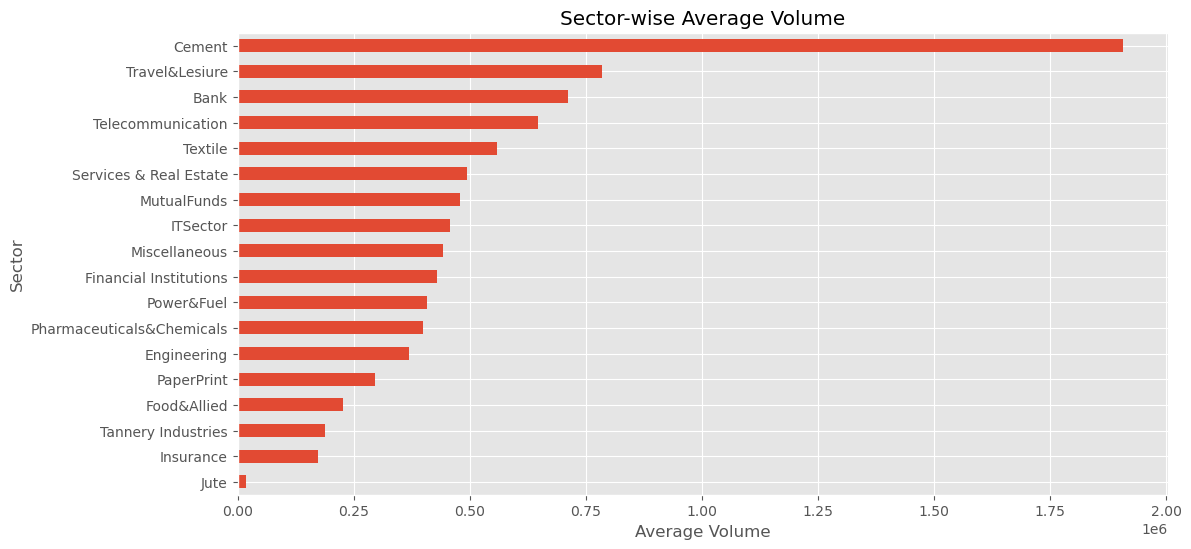

In [64]:
sector_volume = (
    df.groupby("Sector")["Volume"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

sector_volume.plot(kind="barh")

plt.xlabel("Average Volume")

plt.title("Sector-wise Average Volume")

plt.show()

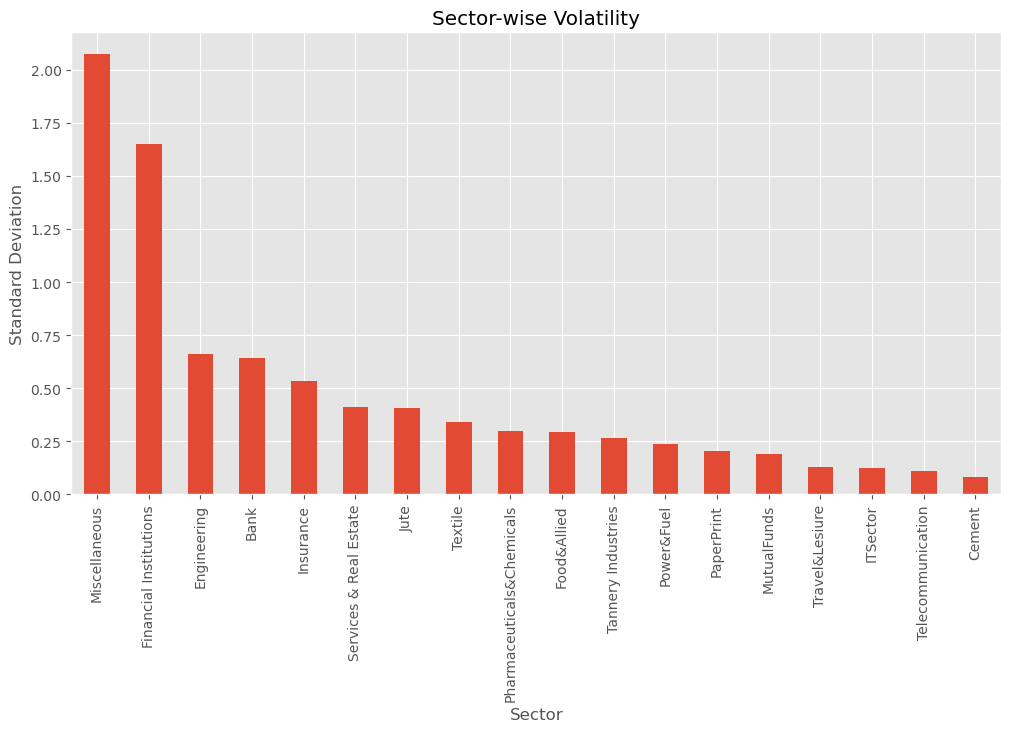

In [65]:
sector_volatility = (
    df.groupby("Sector")["Return"]
      .std()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sector_volatility.plot(kind="bar")

plt.ylabel("Standard Deviation")

plt.title("Sector-wise Volatility")

plt.show()

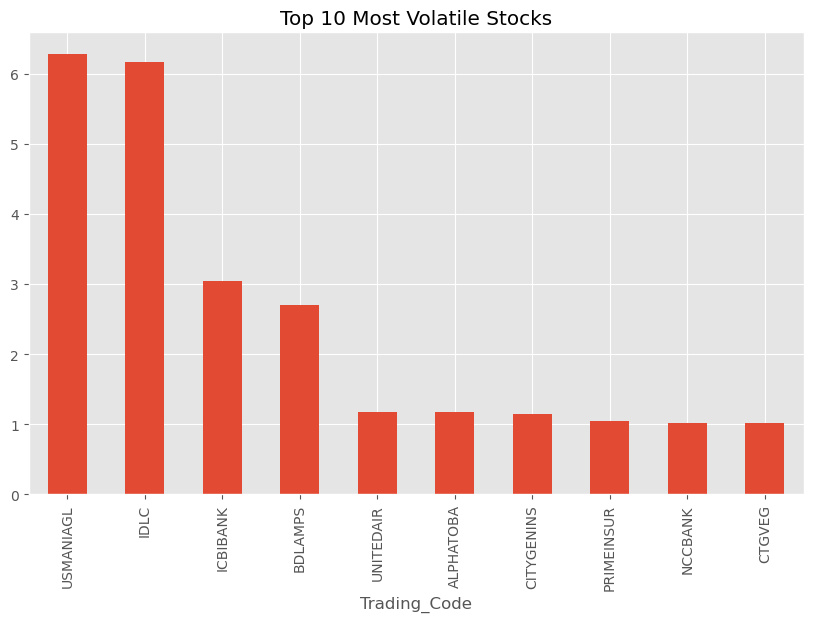

In [66]:
volatility = (
    df.groupby("Trading_Code")["Return"]
      .std()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

volatility.plot(kind="bar")

plt.title("Top 10 Most Volatile Stocks")

plt.show()

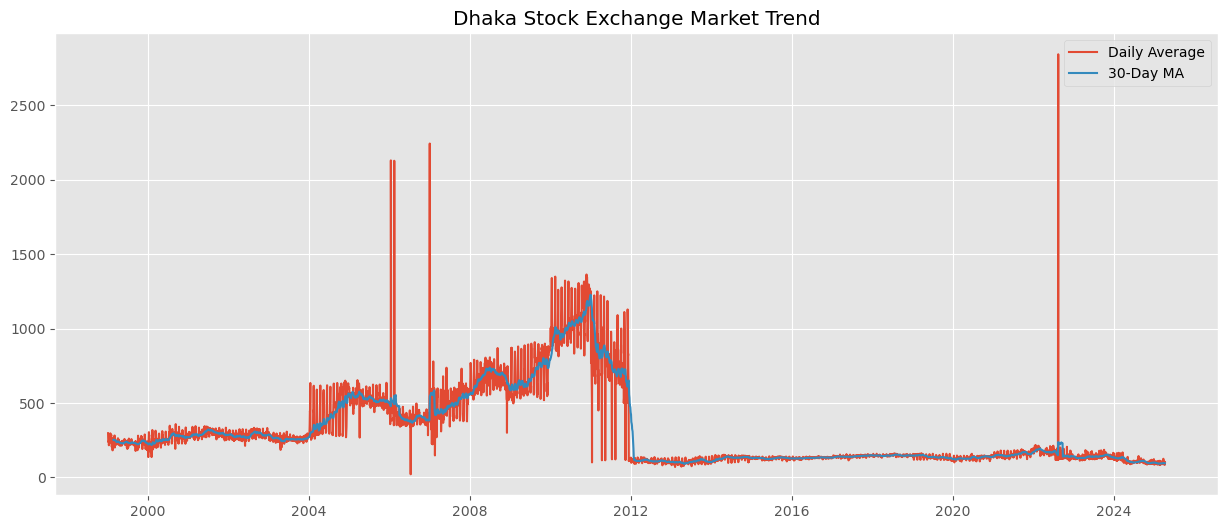

In [67]:
market = (
    df.groupby("Date")["Close"]
      .mean()
)

rolling = market.rolling(30).mean()

plt.figure(figsize=(15,6))

plt.plot(market,label="Daily Average")

plt.plot(rolling,label="30-Day MA")

plt.legend()

plt.title("Dhaka Stock Exchange Market Trend")

plt.show()

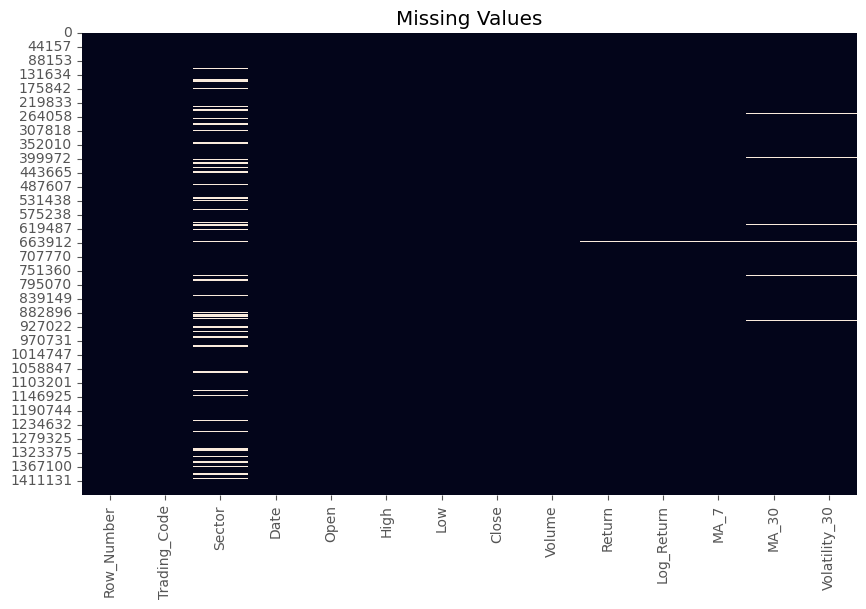

In [68]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")

plt.show()